<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Computer%20Vision/Transfer%20Learning%20K%C3%A9poszt%C3%A1lyoz%C3%A1shoz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning Képosztályozáshoz

A **transfer learning** (átviteli tanulás) az egyik leghatékonyabb technika a modern deep learningben. Az alapötlet: egy nagy adathalmazon (pl. ImageNet) előtanított modell tudását újrahasznosítjuk egy új feladatra.

## Tartalomjegyzék

1. Transfer Learning alapjai
2. Népszerű előtanított modellek
3. Feature Extraction vs Fine-Tuning
4. Gyakorlati implementáció PyTorch-ban
5. Learning Rate stratégiák
6. Best Practices

## 1. Transfer Learning alapjai

### Miért működik?

A CNN-ek hierarchikusan tanulnak jellemzőket:
- **Korai rétegek**: Általános jellemzők (élek, textúrák, színek)
- **Középső rétegek**: Összetettebb minták (formák, részletek)
- **Késői rétegek**: Feladat-specifikus jellemzők

Az általános jellemzők **újrahasznosíthatók** különböző feladatokhoz!

### Transfer Learning előnyei

| Előny | Magyarázat |
|-------|------------|
| Kevesebb adat szükséges | Az előtanított súlyok jó kiindulópontot adnak |
| Gyorsabb tanulás | Nem nulláról kezdünk |
| Jobb általánosítás | ImageNet-en tanult jellemzők robusztusak |
| Erőforrás-hatékony | Nem kell GPU-heteket tölteni tanítással |

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. Népszerű előtanított modellek

### Modell összehasonlítás

| Modell | Paraméterek | Top-1 Acc | Sebesség | Használat |
|--------|-------------|-----------|----------|------------|
| ResNet-18 | 11.7M | 69.8% | Gyors | Gyors prototípus |
| ResNet-50 | 25.6M | 76.1% | Közepes | Általános célú |
| MobileNetV2 | 3.4M | 71.9% | Nagyon gyors | Mobil/Edge |
| EfficientNet-B0 | 5.3M | 77.1% | Közepes | Legjobb acc/param |
| VGG16 | 138M | 71.6% | Lassú | Legacy, feature extraction |

In [7]:
def load_pretrained_models():
    """Előtanított modellek betöltése és összehasonlítása."""

    model_info = {}

    # ResNet-18
    resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model_info['ResNet-18'] = {
        'params': sum(p.numel() for p in resnet18.parameters()),
        'fc_in': resnet18.fc.in_features
    }

    # MobileNetV2
    mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    model_info['MobileNetV2'] = {
        'params': sum(p.numel() for p in mobilenet.parameters()),
        'fc_in': mobilenet.classifier[1].in_features
    }

    # EfficientNet-B0
    efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model_info['EfficientNet-B0'] = {
        'params': sum(p.numel() for p in efficientnet.parameters()),
        'fc_in': efficientnet.classifier[1].in_features
    }

    print("Előtanított modellek összehasonlítása:")
    print("-" * 50)
    for name, info in model_info.items():
        print(f"{name:20s} | Params: {info['params']/1e6:.1f}M | FC input: {info['fc_in']}")

    return model_info

model_info = load_pretrained_models()

Előtanított modellek összehasonlítása:
--------------------------------------------------
ResNet-18            | Params: 11.7M | FC input: 512
MobileNetV2          | Params: 3.5M | FC input: 1280
EfficientNet-B0      | Params: 5.3M | FC input: 1280


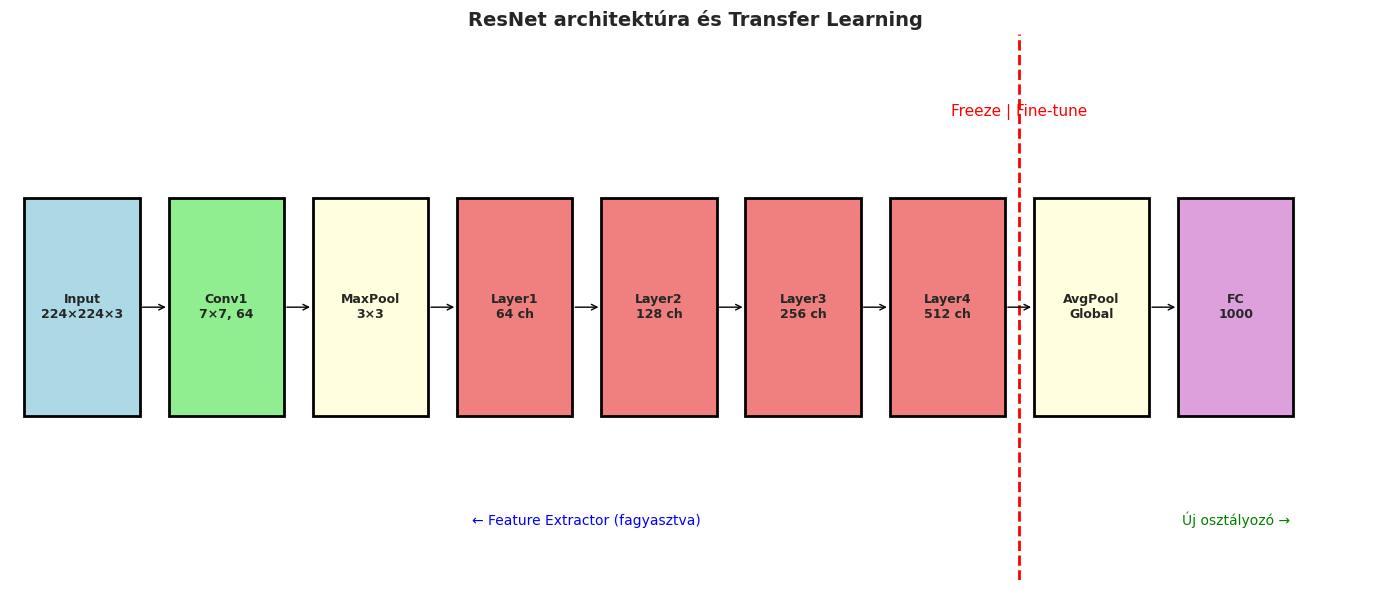

In [8]:
def visualize_resnet_architecture():
    """ResNet architektúra vizualizáció."""

    fig, ax = plt.subplots(figsize=(14, 6))

    # ResNet blokkok
    blocks = [
        ('Input\n224×224×3', 0.5, 'lightblue'),
        ('Conv1\n7×7, 64', 1.5, 'lightgreen'),
        ('MaxPool\n3×3', 2.5, 'lightyellow'),
        ('Layer1\n64 ch', 3.5, 'lightcoral'),
        ('Layer2\n128 ch', 4.5, 'lightcoral'),
        ('Layer3\n256 ch', 5.5, 'lightcoral'),
        ('Layer4\n512 ch', 6.5, 'lightcoral'),
        ('AvgPool\nGlobal', 7.5, 'lightyellow'),
        ('FC\n1000', 8.5, 'plum'),
    ]

    for label, x, color in blocks:
        rect = plt.Rectangle((x-0.4, 0.3), 0.8, 0.4,
                             facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(x, 0.5, label, ha='center', va='center', fontsize=9, fontweight='bold')

    # Nyilak
    for i in range(len(blocks)-1):
        ax.annotate('', xy=(blocks[i+1][1]-0.4, 0.5), xytext=(blocks[i][1]+0.4, 0.5),
                   arrowprops=dict(arrowstyle='->', color='black'))

    # Transfer learning jelölés
    ax.axvline(x=7.0, color='red', linestyle='--', linewidth=2)
    ax.text(7.0, 0.85, 'Freeze | Fine-tune', ha='center', color='red', fontsize=11)
    ax.text(4.0, 0.1, '← Feature Extractor (fagyasztva)', ha='center', fontsize=10, color='blue')
    ax.text(8.5, 0.1, 'Új osztályozó →', ha='center', fontsize=10, color='green')

    ax.set_xlim(0, 9.5)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('ResNet architektúra és Transfer Learning', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_resnet_architecture()

## 3. Feature Extraction vs Fine-Tuning

### Két fő megközelítés:

**1. Feature Extraction (Jellemző kinyerés)**
- Az előtanított rétegek **fagyasztva** maradnak
- Csak az új osztályozó réteg tanul
- Gyors, kevés adat esetén ideális

**2. Fine-Tuning (Finomhangolás)**
- Az előtanított rétegek egy részét is tanítjuk
- Kisebb learning rate a korai rétegekre
- Több adat és idő szükséges

In [9]:
class TransferLearningModel(nn.Module):
    """Transfer learning wrapper különböző backbone-okhoz."""

    def __init__(self, backbone: str = 'resnet18', num_classes: int = 10,
                 freeze_backbone: bool = True):
        super().__init__()

        self.backbone_name = backbone

        if backbone == 'resnet18':
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()  # Eltávolítjuk az eredeti FC-t

        elif backbone == 'mobilenet_v2':
            self.backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()

        elif backbone == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

        # Backbone fagyasztása
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Új osztályozó fejrész
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def unfreeze_backbone(self, layers_to_unfreeze: int = -1):
        """Backbone rétegek feloldása fine-tuninghoz."""
        all_params = list(self.backbone.parameters())

        if layers_to_unfreeze == -1:
            # Minden réteg feloldása
            for param in all_params:
                param.requires_grad = True
        else:
            # Csak az utolsó N réteg feloldása
            for param in all_params[-layers_to_unfreeze:]:
                param.requires_grad = True

    def count_trainable_params(self) -> Tuple[int, int]:
        """Tanítható és összes paraméter számolása."""
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total

# Teszt
model = TransferLearningModel('resnet18', num_classes=5, freeze_backbone=True)
trainable, total = model.count_trainable_params()
print(f"Feature Extraction mód:")
print(f"  Tanítható: {trainable:,} ({100*trainable/total:.1f}%)")
print(f"  Összes: {total:,}")

model.unfreeze_backbone(layers_to_unfreeze=20)
trainable, total = model.count_trainable_params()
print(f"\nFine-tuning mód (utolsó 20 réteg):")
print(f"  Tanítható: {trainable:,} ({100*trainable/total:.1f}%)")

Feature Extraction mód:
  Tanítható: 132,613 (1.2%)
  Összes: 11,309,125

Fine-tuning mód (utolsó 20 réteg):
  Tanítható: 9,117,189 (80.6%)


## 4. Gyakorlati implementáció

### Szintetikus adathalmaz létrehozása demonstrációhoz

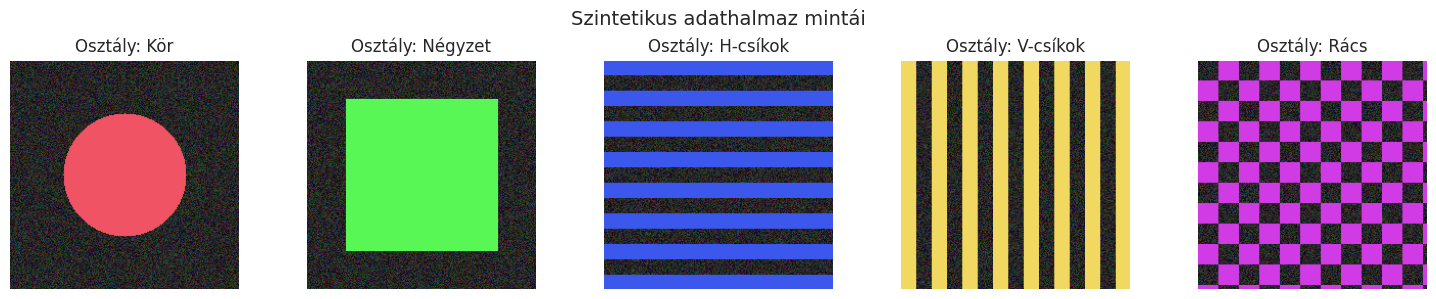

In [19]:
class SyntheticImageDataset(Dataset):
    """Szintetikus képadathalmaz transfer learning demonstrációhoz."""

    def __init__(self, num_samples: int = 500, num_classes: int = 5,
                 img_size: int = 224, transform=None):
        self.num_samples = num_samples
        self.num_classes = num_classes
        self.img_size = img_size
        self.transform = transform

        # Osztályonkénti jellemző színek és minták
        self.class_colors = [
            [0.8, 0.2, 0.2],  # Piros
            [0.2, 0.8, 0.2],  # Zöld
            [0.2, 0.2, 0.8],  # Kék
            [0.8, 0.8, 0.2],  # Sárga
            [0.8, 0.2, 0.8],  # Lila
        ]

        # Adatok előgenerálása
        self.images = []
        self.labels = []

        np.random.seed(42)
        for i in range(num_samples):
            label = i % num_classes
            img = self._generate_image(label)
            self.images.append(img)
            self.labels.append(label)

    def _generate_image(self, label: int) -> np.ndarray:
        """Osztály-specifikus szintetikus kép generálása."""
        img = np.random.rand(self.img_size, self.img_size, 3) * 0.3

        color = self.class_colors[label]

        # Osztály-specifikus alakzat hozzáadása
        cx, cy = self.img_size // 2, self.img_size // 2
        radius = self.img_size // 4 + np.random.randint(-20, 20)

        y, x = np.mgrid[:self.img_size, :self.img_size]

        if label == 0:  # Kör
            mask = (x - cx)**2 + (y - cy)**2 <= radius**2
        elif label == 1:  # Négyzet
            mask = (np.abs(x - cx) <= radius) & (np.abs(y - cy) <= radius)
        elif label == 2:  # Vízszintes csíkok
            mask = (y % 30) < 15
        elif label == 3:  # Függőleges csíkok
            mask = (x % 30) < 15
        else:  # Rács
            mask = ((x % 40) < 20) ^ ((y % 40) < 20)

        for c in range(3):
            img[mask, c] = color[c] + np.random.rand() * 0.2

        return (img * 255).astype(np.uint8)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

# ImageNet normalizálás
imagenet_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    imagenet_normalize,
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    imagenet_normalize,
])

# Adathalmazok
train_dataset = SyntheticImageDataset(400, num_classes=5, transform=train_transform)
val_dataset = SyntheticImageDataset(100, num_classes=5, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Vizualizáció
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
class_names = ['Kör', 'Négyzet', 'H-csíkok', 'V-csíkok', 'Rács']

for i, ax in enumerate(axes):
    idx = i  # Különböző osztályok
    ax.imshow(train_dataset.images[idx])
    ax.set_title(f'Osztály: {class_names[i]}')
    ax.axis('off')

plt.suptitle('Szintetikus adathalmaz mintái', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Egy epoch tanítása."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100 * correct / total


def evaluate(model, loader, criterion, device):
    """Modell kiértékelése."""
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100 * correct / total


def train_model(model, train_loader, val_loader, num_epochs: int = 10,
                lr: float = 0.001, device: str = 'cpu'):
    """Teljes tanítási folyamat."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1:2d} | Train: {train_acc:.1f}% | Val: {val_acc:.1f}%")

    return history

In [21]:
# Feature Extraction tanítás
print("=" * 50)
print("Feature Extraction (fagyasztott backbone)")
print("=" * 50)

model_fe = TransferLearningModel('resnet18', num_classes=5, freeze_backbone=True)
trainable, total = model_fe.count_trainable_params()
print(f"Tanítható paraméterek: {trainable:,} / {total:,}")

history_fe = train_model(model_fe, train_loader, val_loader, num_epochs=10, lr=0.001, device=device)

Feature Extraction (fagyasztott backbone)
Tanítható paraméterek: 132,613 / 11,309,125
Epoch  2 | Train: 97.2% | Val: 100.0%
Epoch  4 | Train: 99.8% | Val: 100.0%
Epoch  6 | Train: 100.0% | Val: 100.0%
Epoch  8 | Train: 100.0% | Val: 100.0%
Epoch 10 | Train: 100.0% | Val: 100.0%


In [22]:
# Fine-Tuning tanítás
print("\n" + "=" * 50)
print("Fine-Tuning (feloldott backbone)")
print("=" * 50)

model_ft = TransferLearningModel('resnet18', num_classes=5, freeze_backbone=True)
model_ft.unfreeze_backbone(layers_to_unfreeze=30)  # Utolsó 30 paraméter
trainable, total = model_ft.count_trainable_params()
print(f"Tanítható paraméterek: {trainable:,} / {total:,}")

history_ft = train_model(model_ft, train_loader, val_loader, num_epochs=10, lr=0.0001, device=device)


Fine-Tuning (feloldott backbone)
Tanítható paraméterek: 10,626,053 / 11,309,125
Epoch  2 | Train: 100.0% | Val: 100.0%
Epoch  4 | Train: 100.0% | Val: 100.0%
Epoch  6 | Train: 100.0% | Val: 100.0%
Epoch  8 | Train: 100.0% | Val: 100.0%
Epoch 10 | Train: 100.0% | Val: 100.0%


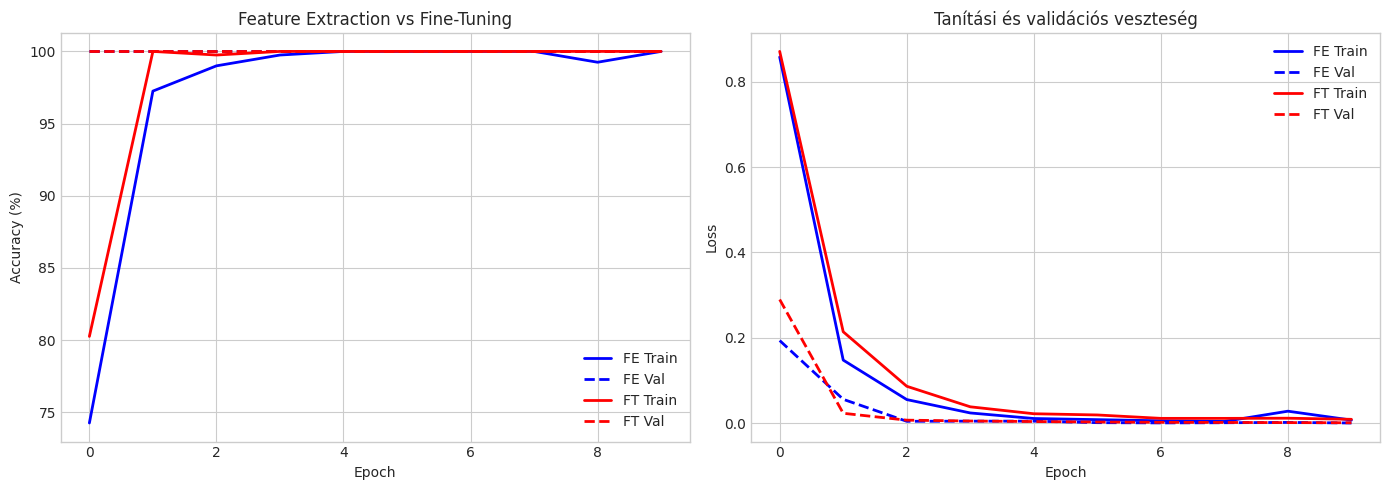

In [23]:
# Eredmények összehasonlítása
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_fe['train_acc'], 'b-', label='FE Train', linewidth=2)
axes[0].plot(history_fe['val_acc'], 'b--', label='FE Val', linewidth=2)
axes[0].plot(history_ft['train_acc'], 'r-', label='FT Train', linewidth=2)
axes[0].plot(history_ft['val_acc'], 'r--', label='FT Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Feature Extraction vs Fine-Tuning')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_fe['train_loss'], 'b-', label='FE Train', linewidth=2)
axes[1].plot(history_fe['val_loss'], 'b--', label='FE Val', linewidth=2)
axes[1].plot(history_ft['train_loss'], 'r-', label='FT Train', linewidth=2)
axes[1].plot(history_ft['val_loss'], 'r--', label='FT Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Tanítási és validációs veszteség')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Learning Rate stratégiák

### Differential Learning Rates

Fine-tuning során különböző learning rate-eket használunk a különböző rétegekhez:
- **Korai rétegek**: Kis LR (általános jellemzők, ne változzanak sokat)
- **Késői rétegek**: Közepes LR (feladat-specifikus adaptáció)
- **Új rétegek**: Nagy LR (nulláról tanulnak)

In [24]:
def get_layer_groups(model, base_lr: float = 1e-4):
    """Réteg csoportok különböző learning rate-ekkel."""

    # ResNet rétegcsoportok
    if hasattr(model.backbone, 'layer4'):
        param_groups = [
            # Korai rétegek: legkisebb LR
            {'params': list(model.backbone.conv1.parameters()) +
                      list(model.backbone.bn1.parameters()) +
                      list(model.backbone.layer1.parameters()),
             'lr': base_lr * 0.1},

            # Középső rétegek
            {'params': list(model.backbone.layer2.parameters()) +
                      list(model.backbone.layer3.parameters()),
             'lr': base_lr * 0.5},

            # Késői rétegek
            {'params': list(model.backbone.layer4.parameters()),
             'lr': base_lr},

            # Új osztályozó: legnagyobb LR
            {'params': model.classifier.parameters(),
             'lr': base_lr * 10},
        ]
    else:
        # Fallback egyszerű csoportosítás
        param_groups = [
            {'params': model.backbone.parameters(), 'lr': base_lr},
            {'params': model.classifier.parameters(), 'lr': base_lr * 10},
        ]

    return param_groups

# Differential LR demonstráció
model_diff_lr = TransferLearningModel('resnet18', num_classes=5, freeze_backbone=False)
param_groups = get_layer_groups(model_diff_lr, base_lr=1e-4)

print("Differential Learning Rates:")
print("-" * 40)
group_names = ['Korai rétegek', 'Középső rétegek', 'Késői rétegek', 'Új osztályozó']
for name, group in zip(group_names, param_groups):
    n_params = sum(p.numel() for p in group['params'])
    print(f"{name:20s} | LR: {group['lr']:.1e} | Params: {n_params:,}")

Differential Learning Rates:
----------------------------------------
Korai rétegek        | LR: 1.0e-05 | Params: 157,504
Középső rétegek      | LR: 5.0e-05 | Params: 2,625,280
Késői rétegek        | LR: 1.0e-04 | Params: 8,393,728
Új osztályozó        | LR: 1.0e-03 | Params: 132,613


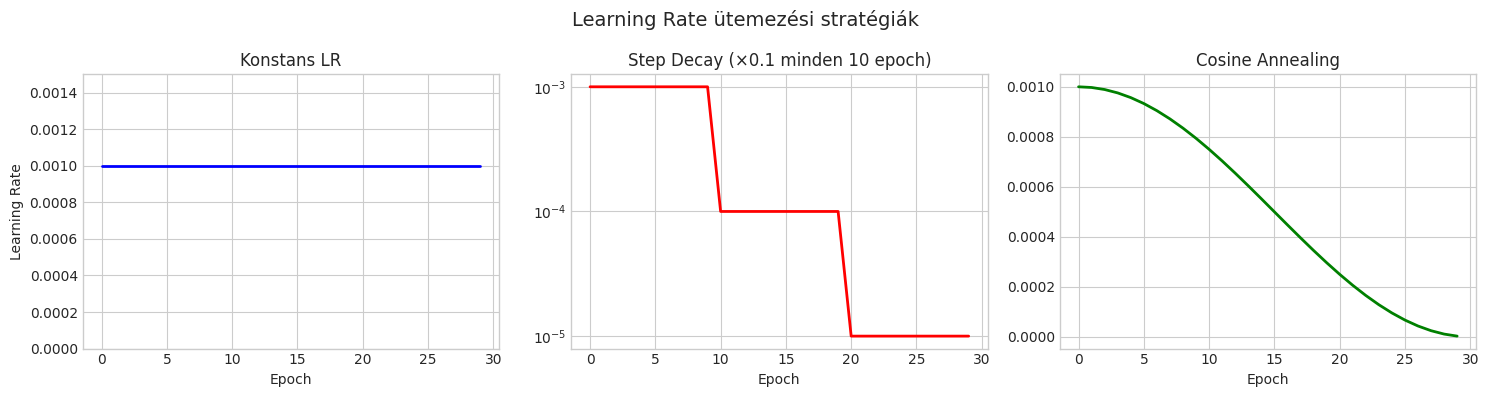

In [25]:
def visualize_lr_strategies():
    """Learning rate stratégiák vizualizációja."""

    epochs = np.arange(30)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Constant LR
    lr_constant = np.ones(30) * 0.001
    axes[0].plot(epochs, lr_constant, 'b-', linewidth=2)
    axes[0].set_title('Konstans LR')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Learning Rate')
    axes[0].set_ylim(0, 0.0015)

    # 2. Step Decay
    lr_step = np.array([0.001 * (0.1 ** (e // 10)) for e in epochs])
    axes[1].plot(epochs, lr_step, 'r-', linewidth=2)
    axes[1].set_title('Step Decay (×0.1 minden 10 epoch)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_yscale('log')

    # 3. Cosine Annealing
    lr_cosine = np.array([0.001 * (1 + np.cos(np.pi * e / 30)) / 2 for e in epochs])
    axes[2].plot(epochs, lr_cosine, 'g-', linewidth=2)
    axes[2].set_title('Cosine Annealing')
    axes[2].set_xlabel('Epoch')

    plt.suptitle('Learning Rate ütemezési stratégiák', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_lr_strategies()

## 6. Best Practices

### Transfer Learning checklist:

1. **Adatmennyiség alapján válassz stratégiát:**
   - Kevés adat (< 1000): Feature extraction
   - Közepes (1000-10000): Fine-tuning utolsó rétegek
   - Sok adat (> 10000): Teljes fine-tuning

2. **Domain hasonlóság:**
   - Hasonló domain → Kevesebb fine-tuning kell
   - Különböző domain → Több réteg fine-tuning

3. **Preprocessing:**
   - Mindig az eredeti modell normalizálását használd (ImageNet mean/std)

4. **Learning rate:**
   - Fine-tuning: 10-100× kisebb mint from-scratch tanítás
   - Differential LR: Korai rétegek << Késői rétegek

In [ ]:
def create_transfer_learning_summary():
    """Transfer learning döntési fa vizualizáció."""

    fig, ax = plt.subplots(figsize=(14, 8))

    # Döntési fa
    nodes = [
        (0.5, 0.9, 'Mennyi adat van?', 'lightblue'),
        (0.2, 0.7, 'Kevés\n(< 1000)', 'lightyellow'),
        (0.5, 0.7, 'Közepes\n(1k-10k)', 'lightyellow'),
        (0.8, 0.7, 'Sok\n(> 10k)', 'lightyellow'),
        (0.2, 0.5, 'Feature\nExtraction', 'lightgreen'),
        (0.5, 0.5, 'Partial\nFine-tuning', 'lightgreen'),
        (0.8, 0.5, 'Full\nFine-tuning', 'lightgreen'),
        (0.2, 0.3, 'Freeze all\nTrain FC only', 'plum'),
        (0.5, 0.3, 'Unfreeze last\n2-3 blocks', 'plum'),
        (0.8, 0.3, 'Train all\nSmall LR', 'plum'),
    ]

    for x, y, text, color in nodes:
        rect = plt.Rectangle((x-0.1, y-0.08), 0.2, 0.12,
                             facecolor=color, edgecolor='black', linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')

    # Nyilak
    connections = [
        (0.5, 0.82, 0.2, 0.78),
        (0.5, 0.82, 0.5, 0.78),
        (0.5, 0.82, 0.8, 0.78),
        (0.2, 0.62, 0.2, 0.58),
        (0.5, 0.62, 0.5, 0.58),
        (0.8, 0.62, 0.8, 0.58),
        (0.2, 0.42, 0.2, 0.38),
        (0.5, 0.42, 0.5, 0.38),
        (0.8, 0.42, 0.8, 0.38),
    ]

    for x1, y1, x2, y2 in connections:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', color='black'))

    # LR ajánlások
    ax.text(0.2, 0.15, 'LR: 1e-3 - 1e-2', ha='center', fontsize=9)
    ax.text(0.5, 0.15, 'LR: 1e-4 - 1e-3', ha='center', fontsize=9)
    ax.text(0.8, 0.15, 'LR: 1e-5 - 1e-4', ha='center', fontsize=9)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.1, 1)
    ax.axis('off')
    ax.set_title('Transfer Learning döntési fa', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

create_transfer_learning_summary()

## Összefoglalás

### Transfer Learning kulcspontok:

| Technika | Mikor használd? | Learning Rate |
|----------|-----------------|---------------|
| Feature Extraction | Kevés adat, hasonló domain | Nagy (1e-3) |
| Partial Fine-tuning | Közepes adat | Közepes (1e-4) |
| Full Fine-tuning | Sok adat, eltérő domain | Kicsi (1e-5) |

### Népszerű backbone-ok:
- **ResNet**: Robusztus, jól dokumentált
- **EfficientNet**: Legjobb accuracy/paraméter arány
- **MobileNet**: Mobil alkalmazásokhoz

### Tipikus workflow:
1. Előtanított modell betöltése
2. Új osztályozó réteg hozzáadása
3. Feature extraction (backbone fagyasztva)
4. Fine-tuning (backbone feloldva, kis LR)